# Thailand Election Policy Extraction

This notebook demonstrates how to extract Thai political party policies from PDF documents using Google Gemini 3 Pro Preview with structured output.

## Features
- Thai Language OCR
- Gemini Structured Output in JSON with Pydantic
- 9-field policy extraction
- Budget normalization
- Category assignment
- Datadog LLM Observability integration

In [1]:
!pip -q install -r ../../../../requirements.txt

In [5]:
!pip freeze | grep -E "google|ddtrace"

ddtrace==4.3.1
google-auth==2.48.0
google-genai==1.60.0


Jupyter Notebook/Lab: Click the Refresh icon (circular arrow) in the toolbar or go to Kernel > Restart

## 1. Setup and Imports

In [7]:
import os
import json
import sys
from pathlib import Path
from typing import Optional
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add scripts directory to path to import extract_policy module
# Notebook is in examples/, so go up to skill root, then into scripts
notebook_dir = Path.cwd()
scripts_dir = notebook_dir.parent / "scripts"
sys.path.insert(0, str(scripts_dir))

# Import extraction functions
from extract_policy import (
    analyze_pdf_with_gemini,
    PoliticalPartyPolicies,
    Policy,
    load_env_file,
    initialize_llmobs
)

print("✓ Imports successful")

✓ Imports successful


## 2. Load Environment Variables

In [8]:
# Load environment variables from .env file
load_env_file()

print("DD_API_KEY:", os.environ.get("DD_API_KEY")[-5:])
print("DD_SITE:", os.environ.get("DD_SITE"))
print("GEMINI_API_KEY:", os.environ.get("GEMINI_API_KEY")[-5:])
print("DD_TRACE_AGENT_PORT:", os.environ.get("DD_TRACE_AGENT_PORT"))

DD_API_KEY: cce05
DD_SITE: datadoghq.com
GEMINI_API_KEY: pZh4s
DD_TRACE_AGENT_PORT: 8136


Loaded environment from: /Users/nuttee.jirattivongvibul/Projects/nuttee-se-gemini-cli/.env


In [9]:
# Verify API key is loaded
api_key = os.environ.get("GEMINI_API_KEY")
if api_key:
    print(f"✓ GEMINI_API_KEY loaded (length: {len(api_key)})")
else:
    print("⚠ GEMINI_API_KEY not found. Please set it in .env file")
    print("   Example: GEMINI_API_KEY=your_api_key_here")

✓ GEMINI_API_KEY loaded (length: 39)


In [10]:
# Initialize Datadog LLM Observability (optional)
initialize_llmobs()

Info: DD_API_KEY ***07dcb


✓ Datadog LLMObs enabled
  ML App: thailand-election-policy-extractor
  Environment: prod


True

## 3. Extract Policies from PDF

### 3.1 Single PDF Extraction

In [11]:
# Set PDF path (update this to your PDF file)
pdf_path = "./เบอร์ 7 พรรคพลวัต.pdf"

# Verify PDF exists
pdf_file = Path(pdf_path)
if pdf_file.exists():
    size_mb = pdf_file.stat().st_size / 1024 / 1024
    print(f"✓ PDF found: {pdf_file.name}")
    print(f"  Size: {size_mb:.2f} MB")
else:
    print(f"⚠ PDF not found: {pdf_path}")
    print("   Please update pdf_path variable above")

✓ PDF found: เบอร์ 7 พรรคพลวัต.pdf
  Size: 4.17 MB


In [12]:
# Define extraction instructions
instructions = """
Extract all policies from this Thai political party document.

For each policy, extract:
1. Policy sequence number (convert Thai numerals ๐-๙ to Arabic 0-9)
2. Policy category (choose from 15 predefined categories)
3. Policy name (extract word by word with high accuracy)
4. Budget in Baht (convert to pure integer: ล้าน=×1M, พันล้าน=×1B, etc.)
5. Funding source (preserve Thai numerals in lists)
6. Cost-effectiveness analysis
7. Benefits description
8. Impacts analysis
9. Risks assessment

Extract ALL policies found in the document. Do not skip any.
"""

# Extract policies
print("Starting extraction...")
print("This may take 3-5 minutes for large PDFs...")

try:
    result_json = analyze_pdf_with_gemini(
        pdf_path=pdf_path,
        instructions=instructions,
        output_format="json",
        use_structured_output=True,
        max_retries=2
    )
    
    # Parse JSON
    policies_data = json.loads(result_json)
    
    print(f"\n✓ Extraction complete!")
    print(f"  Policies extracted: {len(policies_data.get('policies', []))}")
    
except Exception as e:
    print(f"\n✗ Extraction failed: {e}")
    raise

Starting extraction...
This may take 3-5 minutes for large PDFs...
Info: DD_API_KEY ***07dcb


Loaded environment from: /Users/nuttee.jirattivongvibul/Projects/nuttee-se-gemini-cli/.env
✓ Datadog LLMObs enabled
  ML App: thailand-election-policy-extractor
  Environment: prod
Analyzing PDF: เบอร์ 7 พรรคพลวัต.pdf
Output format: json
Structured output: True

Encoding PDF...
PDF size: ~4.2 MB
[11:14:13] Sending request to Gemini 3 Pro Preview...
This may take a moment for large PDFs...
Timeout detection: Will retry if no chunks for >180s

.........
[Chunk 10] ระบบ",       "benefits": "-กลุ่มที่ได้รับประโยชน์ ............
[Chunk 20] ผ่นดิน กระทรวงทรัพยากรและสิ่งแวดล้อม",       "cost............
[Chunk 30] "cost_effectiveness": "ผู้ได้รับผลกระทบจากมลพิษได้............
[Chunk 40]  งบประมาณโดยประมาณ ๑๐ ล้านบาท",       "cost_effect............
[Chunk 50] และสิ่งแวดล้อม",       "cost_effectiveness": "ผู้ไ............
[Chunk 60] 0000,       "funding_source": "-กองทุนพัฒนาพลังงาน............
[Chunk 70] นักเรียนสายอาชีพ” ๓.๓ เศรษฐกิจชุมชน ๓.๔ เศรษฐกิจสร............
[Chunk 80] ใช้งบประมาณแผ่น


✓ Extraction complete!
  Policies extracted: 9




Extraction complete! (99 chunks received)
✓ Validated: 9 policies extracted


failed to send 2 LLMObs span events to http://localhost:8126
Traceback (most recent call last):
  File "/Users/nuttee.jirattivongvibul/Projects/nuttee-se-gemini-cli/.venv/lib/python3.14/site-packages/ddtrace/llmobs/_writer.py", line 263, in _send_payload
    conn.request("POST", self._endpoint, payload, self._headers)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nuttee.jirattivongvibul/Projects/nuttee-se-gemini-cli/.venv/lib/python3.14/site-packages/ddtrace/internal/http.py", line 37, in request
    return super().request(method, url, body=body, headers=_headers, encode_chunked=encode_chunked)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python3.14/http/client.py", line 1358, in request
    self._send_request(method, url, body, headers, encode_chunked)
    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

### 3.2 Save Results

In [13]:
# Save to JSON file
output_file = "party_46_policies.json"

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(policies_data, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {output_file}")

✓ Results saved to: party_46_policies.json


## 4. Explore Extracted Data

In [14]:
# Load policies
policies = policies_data.get('policies', [])

print(f"Total policies: {len(policies)}")
print(f"\nFirst policy:")
if policies:
    first_policy = policies[0]
    print(f"  Sequence: {first_policy['policy_seq']}")
    print(f"  Category: {first_policy['policy_category']}")
    print(f"  Name: {first_policy['policy_name'][:100]}...")
    print(f"  Budget: {first_policy['budget_baht']:,} Baht")

Total policies: 9

First policy:
  Sequence: 1
  Category: นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน
  Name: นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน ๑.๑ รับรองสถานะ “แรงงานนอกระบบ” ๑.๒ สนับสนุนการจัดตั้งสหภาพ/ส...
  Budget: 50,000,000 Baht


In [15]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(policies)

print("DataFrame shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# Display first few rows
df.head()

DataFrame shape: (9, 9)

Column names:
['policy_seq', 'policy_category', 'policy_name', 'budget_baht', 'funding_source', 'cost_effectiveness', 'benefits', 'impacts', 'risks']


,policy_seq,policy_category,policy_name,budget_baht,funding_source,cost_effectiveness,benefits,impacts,risks
0,1,นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน,นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน ๑.๑ รับ...,50000000,งบประมาณแผ่นดิน - กระทรวงแรงงาน - รัฐสภา,"""แรงงานนอกระบบ"" และ ""ฟรีแลนซ์"" ได้รับการคุ้มคร...",-กลุ่มที่ได้รับประโยชน์ โดยตรง คือ แรงงานนอกระ...,"-ยกระดับคนทำงานกว่า 50-60% ของประเทศ จาก ""ตัวเ...",-กองทุนประกันสังคมอาจมีภาระที่สูงขึ้น ประกอบกั...
1,2,นโยบายสิ่งแวดล้อม,นโยบายสิ่งแวดล้อม ๒.๑ พ.ร.บ.อากาศสะอาด,10000000,-งบประมาณแผ่นดิน กระทรวงทรัพยากรและสิ่งแวดล้อม,ผู้ได้รับผลกระทบจากมลพิษได้รับการป้องกันโดยรัฐ...,-กลุ่มคนที่ได้รับผลกระทบจากมลพิษข้ามแดนได้รับผ...,-ลดภาระกลุ่มวิชาชีพทางการแพทย์ -สุขภาพของประชา...,-ปัจจัยที่ควบคุมไม่ได้ เช่น การทูตที่ขึ้นอยู่ก...
2,2,นโยบายสิ่งแวดล้อม,การจัดการมลพิษข้ามพรมแดน,10000000,ใช้งบประมาณแผ่นดินในส่วนของงบกลางเป็นที่ส่วนขอ...,ผู้ได้รับผลกระทบจากมลพิษได้รับการป้องกันโดยรัฐ...,-กลุ่มคนที่ได้รับผลกระทบจากมลพิษข้ามแดนได้รับผ...,-ลดภาระกลุ่มวิชาชีพทางการแพทย์ -สุขภาพของประชา...,-ปัจจัยที่ควบคุมไม่ได้ เช่น การทูตที่ขึ้นอยู่ก...
3,2,นโยบายสิ่งแวดล้อม,๒.๓ กองทุนชดเชยสิ่งแวดล้อม,10000000,สร้างกลไกกองทุนชดเชยโดยใช้งบประมาณแผ่นดินในการ...,ผู้ได้รับผลกระทบจากมลพิษได้รับการป้องกันโดยรัฐ...,-กลุ่มคนที่ได้รับผลกระทบจากมลพิษข้ามแดนได้รับผ...,-ลดภาระกลุ่มวิชาชีพทางการแพทย์ -สุขภาพของประชา...,-ปัจจัยที่ควบคุมไม่ได้ เช่น การทูตที่ขึ้นอยู่ก...
4,2,นโยบายสิ่งแวดล้อม,๒.๔ รถบริการสาธารณะไฟฟ้าโดยการสนับสนุนปลอดดอกเ...,270000000,-งบกองทุนพัฒนาสิ่งแวดล้อม กระทรวงทรัพยากรและสิ...,ผู้ได้รับผลกระทบจากมลพิษได้รับการป้องกันโดยรัฐ...,-.แก้ไขปัญหาเรื่อง PM 2.5 -ประหยัดงบประมาณด้าน...,-ลดปัญหาทางด้านสุขภาพของประชาชนทางด้าน PM 2.5,-ผู้ขับรถแท็กซี่ที่ได้รับเงินอุดหนุนจากรัฐอาจจ...


## 5. Data Analysis and Visualization

In [16]:
# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for Thai fonts (if available)
plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'sans-serif']

### 5.1 Policy Categories Distribution

Policies by Category:
policy_category
นโยบายสิ่งแวดล้อม                         5
นโยบายกระจายอำนาจทางเศรษฐกิจ              3
นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน    1
Name: count, dtype: int64


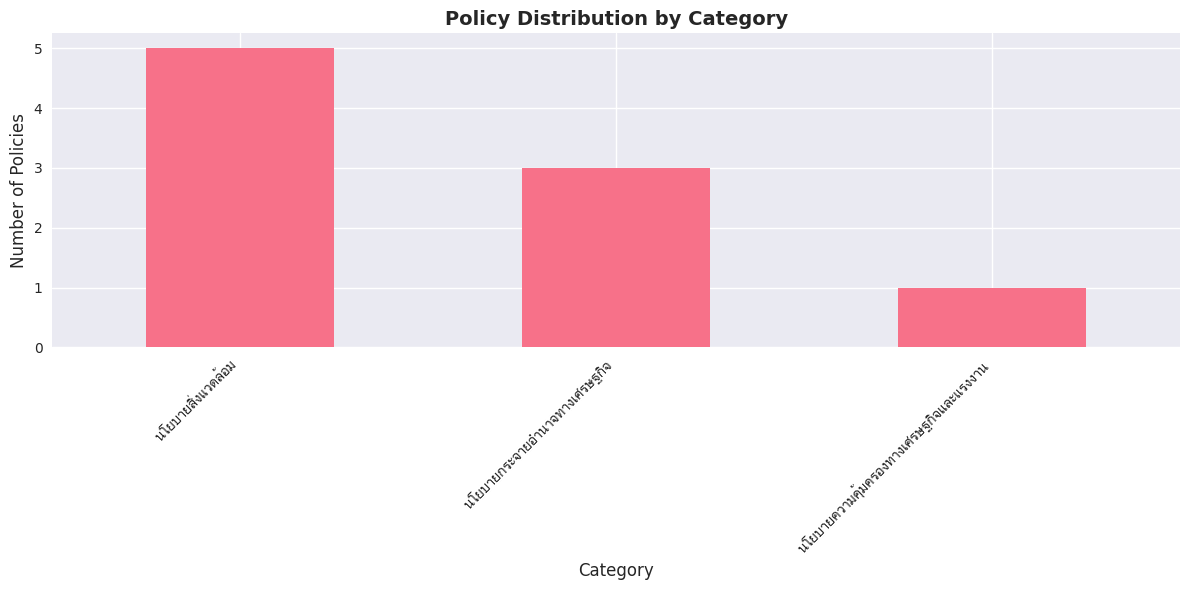

In [17]:
# Count policies by category
category_counts = df['policy_category'].value_counts()

print("Policies by Category:")
print(category_counts)

# Create bar chart
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.title('Policy Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Policies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Budget Analysis

In [18]:
# Filter policies with budget
policies_with_budget = df[df['budget_baht'] > 0].copy()

print(f"Policies with budget: {len(policies_with_budget)} / {len(df)}")
print(f"\nBudget Statistics:")
print(f"  Total budget: {policies_with_budget['budget_baht'].sum():,.0f} Baht")
print(f"  Average budget: {policies_with_budget['budget_baht'].mean():,.0f} Baht")
print(f"  Median budget: {policies_with_budget['budget_baht'].median():,.0f} Baht")
print(f"  Max budget: {policies_with_budget['budget_baht'].max():,.0f} Baht")
print(f"  Min budget: {policies_with_budget['budget_baht'].min():,.0f} Baht")

Policies with budget: 9 / 9

Budget Statistics:
  Total budget: 3,000,000,000 Baht
  Average budget: 333,333,333 Baht
  Median budget: 50,000,000 Baht
  Max budget: 1,500,000,000 Baht
  Min budget: 10,000,000 Baht


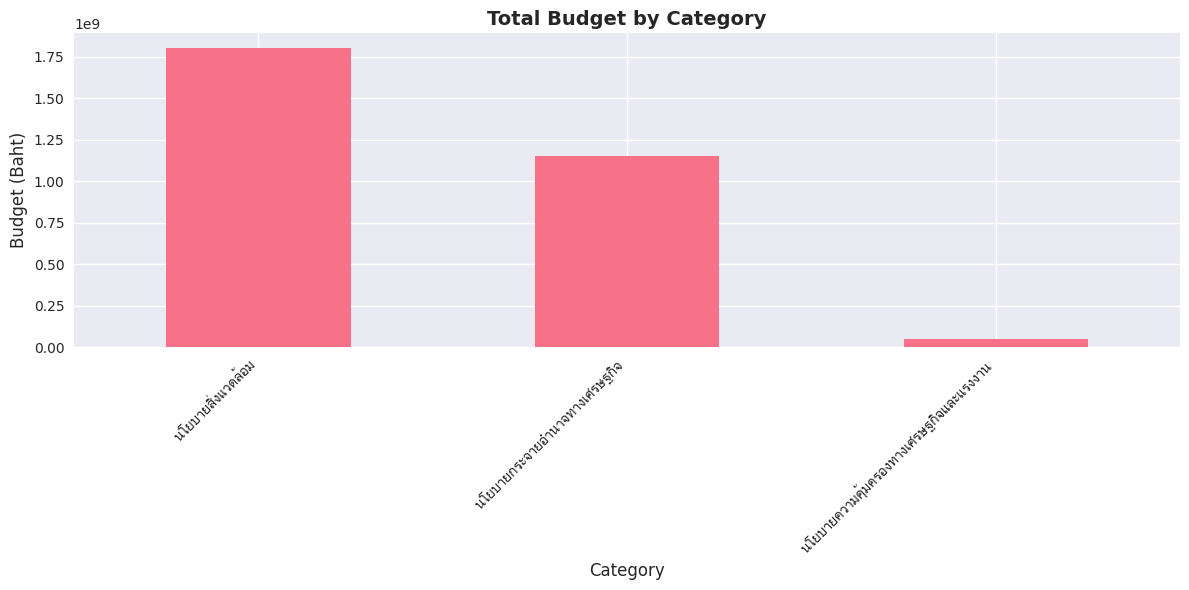


Top 5 categories by budget:
policy_category
นโยบายสิ่งแวดล้อม                         1800000000
นโยบายกระจายอำนาจทางเศรษฐกิจ              1150000000
นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน      50000000
Name: budget_baht, dtype: int64


In [19]:
# Budget by category
if len(policies_with_budget) > 0:
    budget_by_category = policies_with_budget.groupby('policy_category')['budget_baht'].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    budget_by_category.plot(kind='bar')
    plt.title('Total Budget by Category', fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Budget (Baht)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 categories by budget:")
    print(budget_by_category.head())

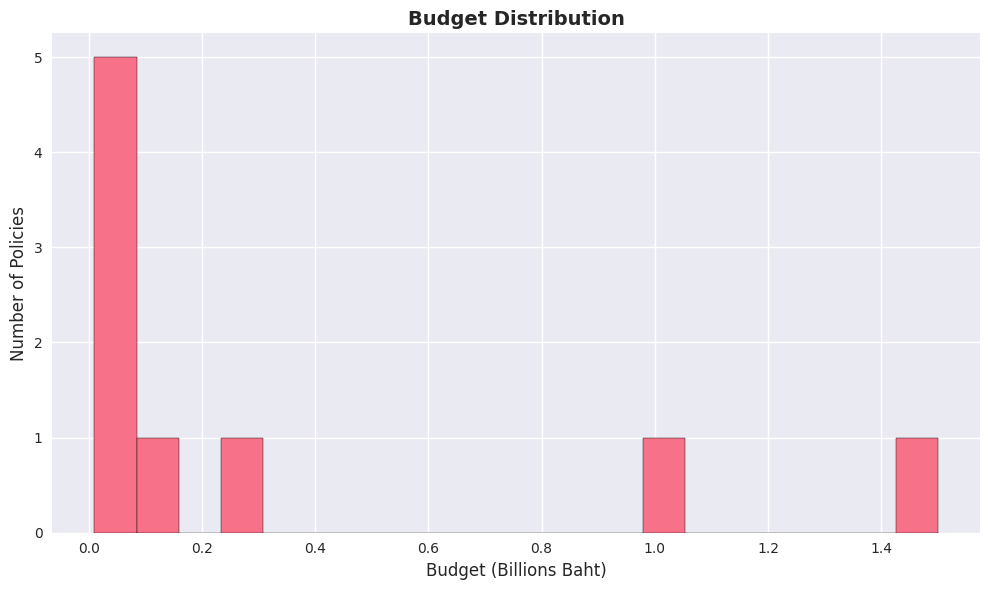

In [20]:
# Budget distribution histogram
if len(policies_with_budget) > 0:
    plt.figure(figsize=(10, 6))
    # Convert to billions for readability
    budget_billions = policies_with_budget['budget_baht'] / 1e9
    plt.hist(budget_billions, bins=20, edgecolor='black')
    plt.title('Budget Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Budget (Billions Baht)', fontsize=12)
    plt.ylabel('Number of Policies', fontsize=12)
    plt.tight_layout()
    plt.show()

### 5.3 Policy Details Table

In [21]:
# Display detailed policy table
display_df = df[['policy_seq', 'policy_category', 'policy_name', 'budget_baht']].copy()
display_df['budget_baht'] = display_df['budget_baht'].apply(lambda x: f"{x:,}" if x > 0 else "N/A")
display_df['policy_name'] = display_df['policy_name'].apply(lambda x: x[:50] + "..." if len(x) > 50 else x)

print("Policy Summary Table:")
display_df.head(10)

Policy Summary Table:


,policy_seq,policy_category,policy_name,budget_baht
0,1,นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน,นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน ๑.๑ รับ...,"50,000,000"
1,2,นโยบายสิ่งแวดล้อม,นโยบายสิ่งแวดล้อม ๒.๑ พ.ร.บ.อากาศสะอาด,"10,000,000"
2,2,นโยบายสิ่งแวดล้อม,การจัดการมลพิษข้ามพรมแดน,"10,000,000"
3,2,นโยบายสิ่งแวดล้อม,๒.๓ กองทุนชดเชยสิ่งแวดล้อม,"10,000,000"
4,2,นโยบายสิ่งแวดล้อม,๒.๔ รถบริการสาธารณะไฟฟ้าโดยการสนับสนุนปลอดดอกเ...,"270,000,000"
5,2,นโยบายสิ่งแวดล้อม,๒.๕ จัดสรรพื้นที่ใต้ทางด่วน เป็นจุดจอดและสถานี...,"1,500,000,000"
6,3,นโยบายกระจายอำนาจทางเศรษฐกิจ,นโยบายกระจายอำนาจทางเศรษฐกิจ ๓.๑ จังหวัดจัดการ...,"50,000,000"
7,3,นโยบายกระจายอำนาจทางเศรษฐกิจ,๓.๒ ใช้งบประมาณแผ่นดินและงบที่อยู่ในกระทรวงเพื...,"100,000,000"
8,3,นโยบายกระจายอำนาจทางเศรษฐกิจ,๓.๓ ใช้งบประมาณแผ่นดินในการเพิ่มศักยภาพแก่ชุมช...,"1,000,000,000"


## 6. Export to CSV

In [22]:
# Export to CSV
csv_file = "party_46_policies.csv"
df.to_csv(csv_file, index=False, encoding='utf-8-sig')

print(f"✓ Exported to CSV: {csv_file}")
print(f"  Rows: {len(df)}")
print(f"  Columns: {len(df.columns)}")

✓ Exported to CSV: party_46_policies.csv
  Rows: 9
  Columns: 9


## 7. Advanced Analysis Examples

### 7.1 Find Policies by Keyword

In [23]:
# Search for policies containing specific keywords
keyword = "สุขภาพ"  # Health

matching_policies = df[df['policy_name'].str.contains(keyword, case=False, na=False)]

print(f"Policies containing '{keyword}': {len(matching_policies)}")
print("\nMatching policies:")
for idx, policy in matching_policies.iterrows():
    print(f"\n{policy['policy_seq']}. {policy['policy_name'][:80]}...")
    print(f"   Category: {policy['policy_category']}")
    if policy['budget_baht'] > 0:
        print(f"   Budget: {policy['budget_baht']:,} Baht")

Policies containing 'สุขภาพ': 0

Matching policies:


### 7.2 Analyze Funding Sources

In [24]:
# Extract unique funding sources
funding_sources = df['funding_source'].unique()

print(f"Unique funding sources mentioned: {len(funding_sources)}")
print("\nSample funding sources:")
for i, source in enumerate(funding_sources[:5], 1):
    if source and source.strip():
        print(f"{i}. {source[:100]}...")

Unique funding sources mentioned: 7

Sample funding sources:
1. งบประมาณแผ่นดิน - กระทรวงแรงงาน - รัฐสภา...
2. -งบประมาณแผ่นดิน กระทรวงทรัพยากรและสิ่งแวดล้อม...
3. ใช้งบประมาณแผ่นดินในส่วนของงบกลางเป็นที่ส่วนของเจ้าหน้าที่ข้าราชการในกระทรวงต่างประเทศการดำเนินการทา...
4. สร้างกลไกกองทุนชดเชยโดยใช้งบประมาณแผ่นดินในการจัดตั้งคณะกรรมการกองทุน อัตราค่าตอบแทน เบี้ยประชุม ฐาน...
5. -งบกองทุนพัฒนาสิ่งแวดล้อม กระทรวงทรัพยากรและสิ่งแวดล้อม...


### 7.3 Risk Analysis

In [25]:
# Policies with risk assessments
policies_with_risks = df[df['risks'].str.len() > 10].copy()

print(f"Policies with detailed risk assessments: {len(policies_with_risks)}")
print("\nSample risk assessments:")
for idx, policy in policies_with_risks.head(3).iterrows():
    print(f"\nPolicy {policy['policy_seq']}: {policy['policy_name'][:60]}...")
    print(f"Risks: {policy['risks'][:150]}...")

Policies with detailed risk assessments: 9

Sample risk assessments:

Policy 1: นโยบายความคุ้มครองทางเศรษฐกิจและแรงงาน ๑.๑ รับรองสถานะ “แรงง...
Risks: -กองทุนประกันสังคมอาจมีภาระที่สูงขึ้น ประกอบกับโครงสร้างประชากรของสังคมผู้สูงอายุ อาจทำให้เงินกองทุนอยู่ในภาวะที่ไม่เพียงพอ...

Policy 2: นโยบายสิ่งแวดล้อม ๒.๑ พ.ร.บ.อากาศสะอาด...
Risks: -ปัจจัยที่ควบคุมไม่ได้ เช่น การทูตที่ขึ้นอยู่กับเจรจาระหว่างประเทศว่าจะให้ความร่วมมือหรือไม่...

Policy 2: การจัดการมลพิษข้ามพรมแดน...
Risks: -ปัจจัยที่ควบคุมไม่ได้ เช่น การทูตที่ขึ้นอยู่กับเจรจาระหว่างประเทศว่าจะให้ความร่วมมือหรือไม่...


## 8. Batch Processing Example

In [26]:
# Example: Process multiple PDFs
pdf_directory = Path("../../temp_working/OTHERS/THAILAND_ELECTION_2026/นโยบายพรรคการเมือง/processed")

if pdf_directory.exists():
    pdf_files = list(pdf_directory.glob("*.pdf"))
    print(f"Found {len(pdf_files)} PDF files")
    print("\nSample files:")
    for pdf_file in pdf_files[:5]:
        print(f"  - {pdf_file.name}")
else:
    print(f"Directory not found: {pdf_directory}")

Directory not found: ../../temp_working/OTHERS/THAILAND_ELECTION_2026/นโยบายพรรคการเมือง/processed


In [ ]:
# Batch processing function (example - uncomment to use)
"""
def batch_extract_pdfs(pdf_directory, output_dir="extracted_policies"):
    """Extract policies from all PDFs in a directory"""
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    pdf_files = list(Path(pdf_directory).glob("*.pdf"))
    results = []
    
    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        
        try:
            result_json = analyze_pdf_with_gemini(
                pdf_path=str(pdf_file),
                instructions=instructions,
                output_format="json",
                use_structured_output=True,
                max_retries=2
            )
            
            # Save individual result
            output_file = output_path / f"{pdf_file.stem}_policies.json"
            with open(output_file, 'w', encoding='utf-8') as f:
                f.write(result_json)
            
            policies_data = json.loads(result_json)
            results.append({
                'file': pdf_file.name,
                'policies_count': len(policies_data.get('policies', []))
            })
            
            print(f"  ✓ Extracted {len(policies_data.get('policies', []))} policies")
            
        except Exception as e:
            print(f"  ✗ Failed: {e}")
            results.append({
                'file': pdf_file.name,
                'policies_count': 0,
                'error': str(e)
            })
    
    return results

# Uncomment to run batch processing
# batch_results = batch_extract_pdfs(pdf_directory)
# print(f"\nBatch processing complete: {len(batch_results)} files processed")
"""

## 9. Summary Statistics

In [ ]:
# Generate summary report
print("=" * 60)
print("EXTRACTION SUMMARY")
print("=" * 60)
print(f"\nTotal Policies Extracted: {len(df)}")
print(f"\nCategories:")
for category, count in category_counts.items():
    print(f"  {category}: {count}")

if len(policies_with_budget) > 0:
    print(f"\nBudget Information:")
    print(f"  Policies with budget: {len(policies_with_budget)}")
    print(f"  Total budget: {policies_with_budget['budget_baht'].sum():,.0f} Baht")
    print(f"  Average budget per policy: {policies_with_budget['budget_baht'].mean():,.0f} Baht")

print(f"\nOutput Files:")
print(f"  JSON: {output_file}")
print(f"  CSV: {csv_file}")
print("\n" + "=" * 60)

## 10. Next Steps

1. **Send to Datadog**: Use `send_to_datadog.py` to upload policies for analysis
2. **Compare Parties**: Extract multiple parties and compare policies
3. **Create Dashboards**: Visualize policy data in Datadog
4. **Export for Analysis**: Use CSV/JSON files in other tools (Excel, Tableau, etc.)

## Resources

- **Script Documentation**: See `SKILL.md` for detailed usage
- **Batch Processing**: Use `batch_extract_all.sh` for multiple PDFs
- **Datadog Integration**: See `LLMOBS_INTEGRATION.md` for tracing setup